<a href="https://colab.research.google.com/github/jeevanshibatra27-create/part-1-neural-network-analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/customer_churn_nn.csv')

# Show first 5 rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
# Number of rows and columns
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

Shape of dataset: (2000, 17)

Columns:
Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
aut

In [4]:
# Missing values check
print("Missing Values:\n")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:\n")
print(df.describe())

Missing Values:

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

Statistical Summary:

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.

churn
0    1969
1      31
Name: count, dtype: int64


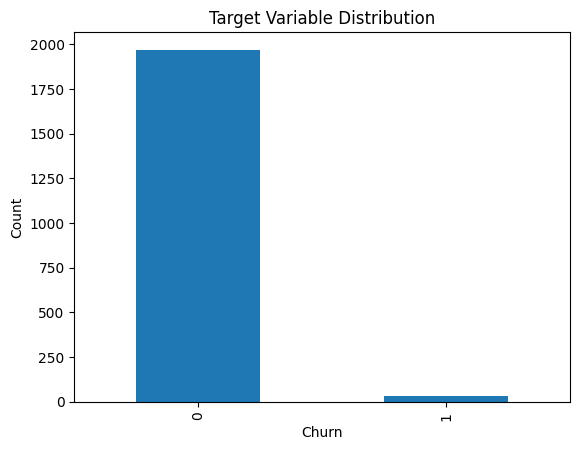

In [11]:
import matplotlib.pyplot as plt

# Target variable distribution
print(df['churn'].value_counts())

# Plot distribution
df['churn'].value_counts().plot(kind='bar')

plt.title("Target Variable Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [13]:
# Data Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Convert categorical columns into numerical
label_encoder = LabelEncoder()

categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method', 'autopay_enabled']

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

# Features and target
X = df.drop(['customer_id', 'churn'], axis=1)
y = df['churn']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 15)
Testing Data Shape: (400, 15)


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create model
model = Sequential()

# Input + Hidden Layer
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Second Hidden Layer
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Train Model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9867 - loss: 0.0579 - val_accuracy: 0.9781 - val_loss: 0.0924
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9867 - loss: 0.0567 - val_accuracy: 0.9781 - val_loss: 0.0927
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0553 - val_accuracy: 0.9781 - val_loss: 0.0917
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9867 - loss: 0.0540 - val_accuracy: 0.9781 - val_loss: 0.0916
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0530 - val_accuracy: 0.9781 - val_loss: 0.0917
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0519 - val_accuracy: 0.9781 - val_loss: 0.0916
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0505 - val_accuracy: 0.9781 - val_loss: 0.0918
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0494 - val_accuracy: 0.9781 - val_loss

In [18]:
#  Model Evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Convert probabilities to 0 and 1
y_pred = (y_pred > 0.5).astype(int)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Test Accuracy: 0.9825

Confusion Matrix:

[[393   0]
 [  7   0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


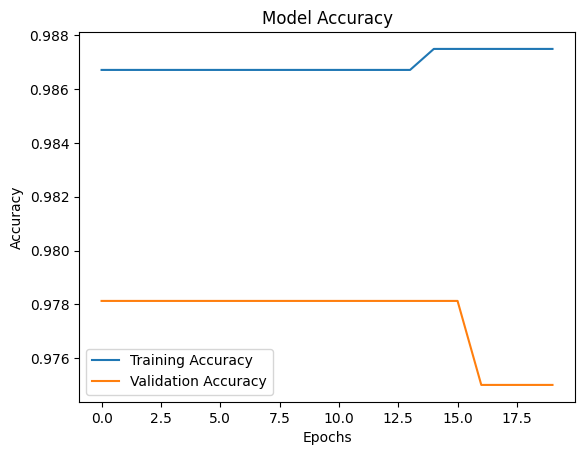

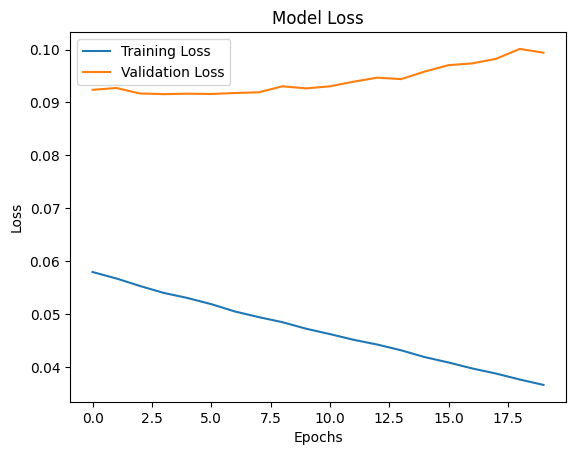

In [25]:
# Training Accuracy & Loss Graph

import matplotlib.pyplot as plt

# Accuracy Graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [27]:
# Hyperparameter Experiment 1

model1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

history1 = model1.fit(X_train, y_train,
                      epochs=10,
                      batch_size=32,
                      verbose=0)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

print("Experiment 1 Accuracy:", acc1)

Experiment 1 Accuracy: 0.9825000166893005


In [23]:
# Hyperparameter Experiment 3

model3 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

history3 = model3.fit(X_train, y_train,
                      epochs=30,
                      batch_size=64,
                      verbose=0)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)

print("Experiment 3 Accuracy:", acc3)

Experiment 3 Accuracy: 0.9800000190734863


In [29]:
# Re-run Experiment 2

model2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

print("Experiment 2 Accuracy:", acc2)

Experiment 2 Accuracy: 0.9825000166893005


In [31]:
# Comparison Table

import pandas as pd

comparison_table = pd.DataFrame({
    'Experiment': ['Experiment 1', 'Experiment 2', 'Experiment 3'],
    'Hidden Layers/Neurons': ['16-8', '32-16', '64-32'],
    'Activation Function': ['ReLU', 'ReLU', 'Tanh'],
    'Epochs': [10, 20, 30],
    'Batch Size': [32, 16, 64],
    'Test Accuracy': [
        float(acc1),
        float(acc2),
        float(acc3)
    ]
})

print(comparison_table)

# Save CSV
comparison_table.to_csv('model_comparison_table.csv', index=False)

     Experiment Hidden Layers/Neurons Activation Function  Epochs  Batch Size  \
0  Experiment 1                  16-8                ReLU      10          32   
1  Experiment 2                 32-16                ReLU      20          16   
2  Experiment 3                 64-32                Tanh      30          64   

   Test Accuracy  
0         0.9825  
1         0.9825  
2         0.9800  


In [32]:
# Final Comparison Table

import pandas as pd

comparison_table = pd.DataFrame({
    'Experiment': ['Experiment 1', 'Experiment 2', 'Experiment 3'],
    'Hidden Layers/Neurons': ['16-8', '32-16', '64-32'],
    'Activation Function': ['ReLU', 'ReLU', 'Tanh'],
    'Epochs': [10, 20, 30],
    'Batch Size': [32, 16, 64],
    'Test Accuracy': [
        float(acc1),
        float(acc2),
        float(acc3)
    ]
})

print(comparison_table)

# Save comparison table
comparison_table.to_csv('model_comparison_table.csv', index=False)

     Experiment Hidden Layers/Neurons Activation Function  Epochs  Batch Size  \
0  Experiment 1                  16-8                ReLU      10          32   
1  Experiment 2                 32-16                ReLU      20          16   
2  Experiment 3                 64-32                Tanh      30          64   

   Test Accuracy  
0         0.9825  
1         0.9825  
2         0.9800  


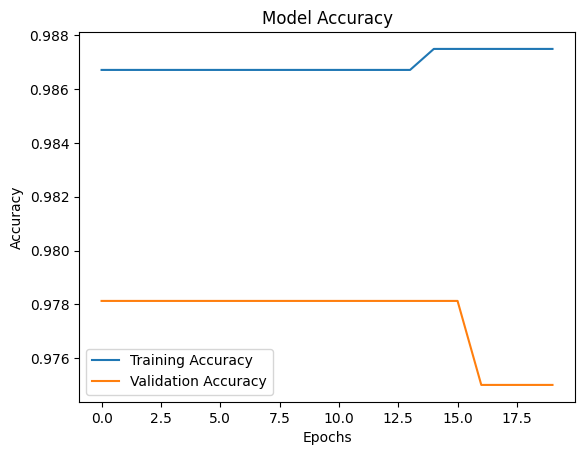

In [33]:
# Save Accuracy Graph

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('evaluation_outputs.png')

plt.show()